In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv


**Load Data**

In [5]:
train=pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv")
test=pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv")
train.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


In [6]:
test.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0


In [7]:
train.shape

(40000, 12)

**Identify Data Types of Columns**

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


In [9]:
train.dtypes

id               int64
airline         object
flight          object
source          object
departure       object
stops           object
arrival         object
destination     object
class           object
duration       float64
days_left      float64
price            int64
dtype: object

**Descriptive Statistics of Numerical Columns**

In [10]:
train.describe()

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


**Total Missing Values**

In [11]:
train.isnull().sum()

id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64

**Imputing Categorical Columns (Airline,Departure and Stops)**

In [12]:
train['airline'].fillna('Unknown', inplace=True)
train['departure'].fillna(train['departure'].mode()[0], inplace=True)
train['stops'].fillna(train['stops'].mode()[0],inplace=True)

In [13]:
print(train['departure'].mode())

0    Morning
Name: departure, dtype: object


**Imputing Numerical Columns (Duration And Days_Left)**

In [14]:
train['duration'].fillna(train['duration'].median(),inplace=True)
train['days_left'].fillna(train['days_left'].median(),inplace=True)

**Check**

In [15]:
train.isnull().sum()

id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64

**Identifying Duplicates**

In [16]:
train.duplicated().sum() 
# No duplicates

0

**Checking Outliers**

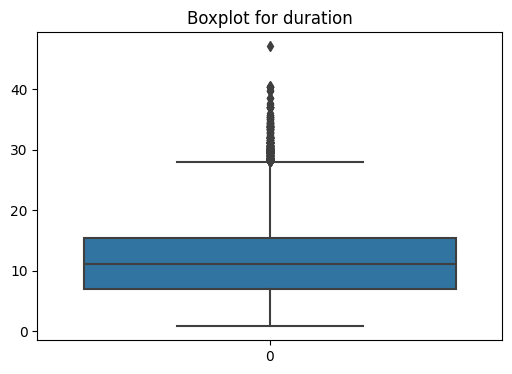

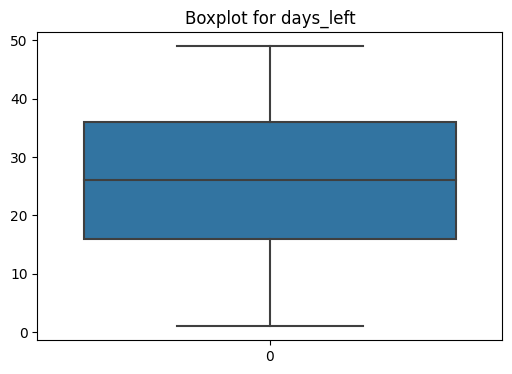

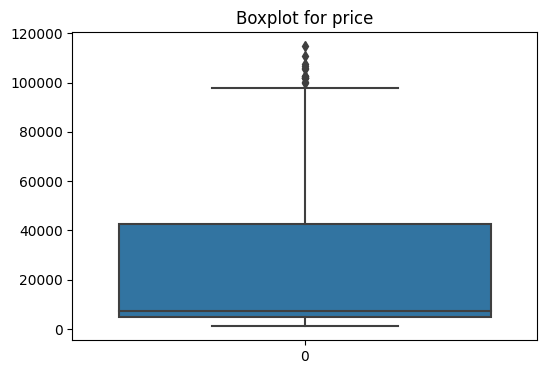

In [17]:
for col in ["duration","days_left","price"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(train[col])
    plt.title(f'Boxplot for {col}')
    plt.show
               

**Handling Outliers**

In [18]:
for col in ["duration","days_left","price"]: 
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    train[col] = train[col].apply(
        lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x
    )


**Check**

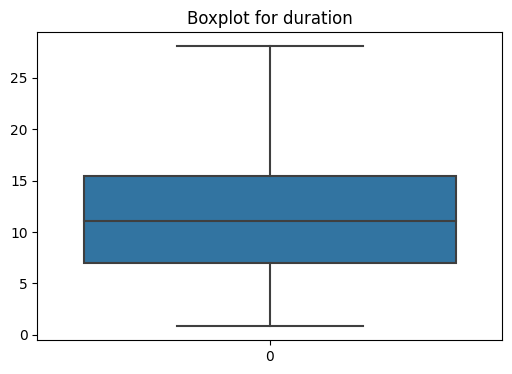

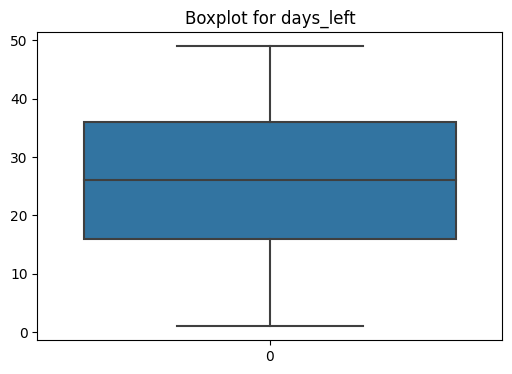

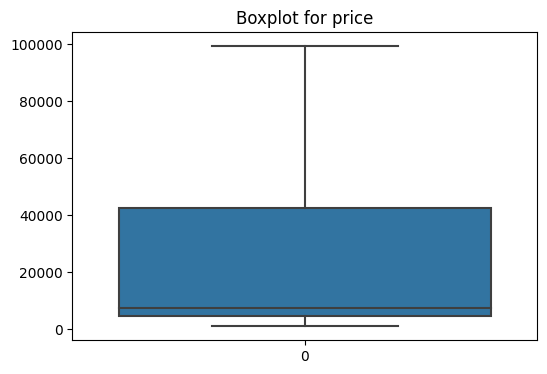

In [19]:
for col in ["duration","days_left","price"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(train[col])
    plt.title(f'Boxplot for {col}')
    plt.show

**Visualization**

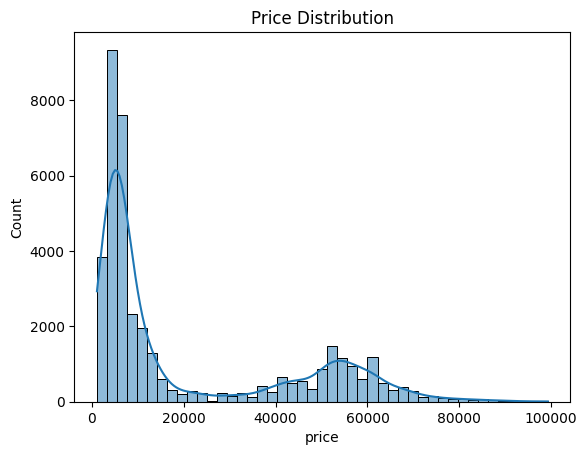

In [20]:
#Price disrtibution
sns.histplot(train['price'], kde=True)
plt.title('Price Distribution')
plt.show()

# Insights
# Majority of flight prices are concentrated on the lower end (around 0 to ~10,000).
# There are long tails towards higher prices, indicating a few very expensive flights.

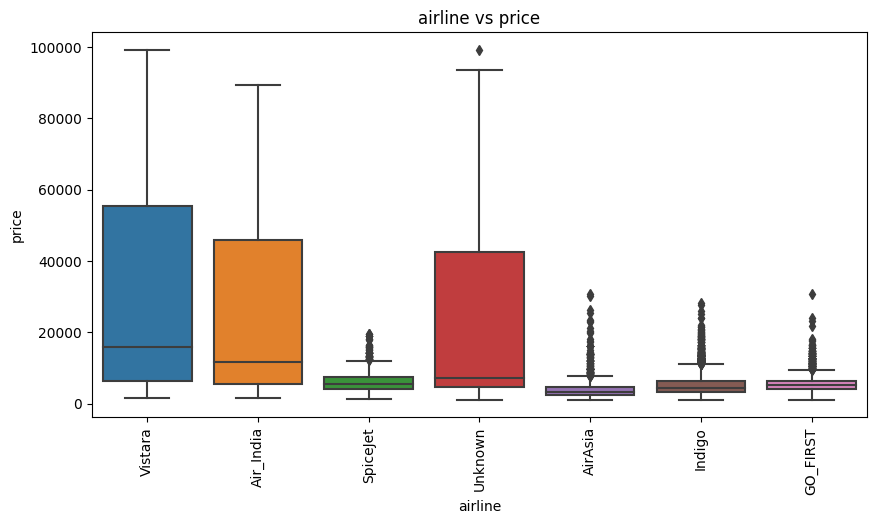

In [21]:
# airline vs price
plt.figure(figsize=(10,5))
sns.boxplot(x='airline', y='price', data=train)
plt.xticks(rotation=90)
plt.title('airline vs price')
plt.show()

# Insights

# Full-service airlines (Vistara, Air India) have significantly higher and more variable prices compared to budget airlines (Indigo, AirAsia, SpiceJet).
# Outliers exist for all airlines, but budget airlines have many outliers likely due to last-minute or peak-season bookings.


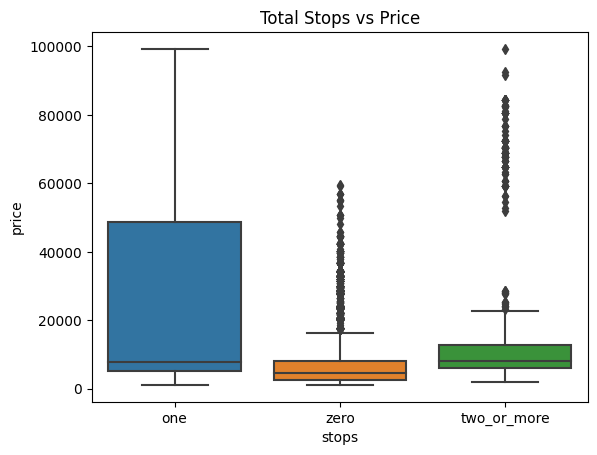

In [22]:
# stops vs price
sns.boxplot(x='stops', y='price', data=train)
plt.title('Total Stops vs Price')
plt.show()

# Insights

# Surprisingly, flights with one stop tend to have higher prices and much larger price variation compared to zero or multiple stops.
# Non-stop flights (zero stops) have lower and more stable prices, though some high outliers exist.
# Two or more stops generally have moderate prices, but with many outliers.

In [23]:
scaler = StandardScaler()
train[['price']] = scaler.fit_transform(train[['price']])


**Scale Numerical features and Encode Categorical features**

In [24]:
X=train.drop("price",axis=1)
y=train["price"]
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
# Select your columns
nominal_cols = ["airline","flight","source","destination"]
ordinal_cols = ["departure","stops","arrival","class"]
numerical_cols = ["id","duration","days_left"]

# Ordinal categories
ordinal_categories = [
    ["Early_Morning","Morning","Afternoon","Evening","Night","Late_Night"],
    ["one","zero","two_or_more"],
    ["Early_Morning","Morning","Afternoon","Evening","Night","Late_Night"],
    ["Business", "Economy"]
]
preprocessor = ColumnTransformer(transformers=[
    ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
    ("nom", OneHotEncoder(drop="first",handle_unknown='ignore'), nominal_cols)
], remainder="passthrough")



In [26]:
train_encoded = preprocessor.fit_transform(X)


In [27]:


X_train, X_val, y_train, y_val = train_test_split(train_encoded, y, test_size=0.2, random_state=42)


In [28]:

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'XGBoost': XGBRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'Ridge': Ridge(solver='lsqr') 
}

In [29]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results[name] = rmse

# Show results
for name, rmse in results.items():
    print(f"{name}: RMSE = {rmse}")

Linear Regression: RMSE = 0.2958943159731195
Decision Tree: RMSE = 0.20331036875861888
Random Forest: RMSE = 0.15518229016933283
Gradient Boosting: RMSE = 0.22740773913145043
XGBoost: RMSE = 0.17162572678077018
AdaBoost: RMSE = 0.2737113669240341
Ridge: RMSE = 0.9638751726530763


**Hypertuning**

In [30]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)

print("Best params Random Forest:", grid.best_params_)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_val, grid.predict(X_val))))


Best params Random Forest: {'max_depth': 20, 'n_estimators': 200}
Random Forest RMSE: 0.1635436836683623


In [31]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)

print("Best params Gradient Boosting:", grid.best_params_)
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_val, grid.predict(X_val))))


Best params Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Gradient Boosting RMSE: 0.1730919561655439


In [32]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)

print("Best params Gradient Boosting:", grid.best_params_)
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_val, grid.predict(X_val))))


Best params Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Gradient Boosting RMSE: 0.1730919561655439


**Comparison of Models**

In [33]:
for model, rmse in results.items():
    print(f'{model}: RMSE = {rmse}')


Linear Regression: RMSE = 0.2958943159731195
Decision Tree: RMSE = 0.20331036875861888
Random Forest: RMSE = 0.15518229016933283
Gradient Boosting: RMSE = 0.22740773913145043
XGBoost: RMSE = 0.17162572678077018
AdaBoost: RMSE = 0.2737113669240341
Ridge: RMSE = 0.9638751726530763


In [34]:
# Fill missing values in categorical columns with mode
for col in nominal_cols + ordinal_cols:
    test[col].fillna(test[col].mode()[0], inplace=True)
# Fill missing values in numerical columns
for col in numerical_cols:
    test[col].fillna(test[col].median(), inplace=True)  # or use mean


In [35]:
# 1️ First, apply preprocessing on test data
X_test = test[nominal_cols + ordinal_cols + numerical_cols]
X_test_encoded = preprocessor.transform(X_test)


# Get the best model
best_model = grid.best_estimator_

# Make predictions on test data
test_predictions_scaled = best_model.predict(X_test_encoded)

# Inverse transform to get back original price
test_predictions = scaler.inverse_transform(test_predictions_scaled.reshape(-1, 1)).ravel()
# Create submission file
submission = pd.DataFrame({
    'id': test['id'],
    'Price': test_predictions
})
submission.to_csv('submission.csv', index=False)



In [36]:
print(submission.head())

   id         Price
0   0   4897.788209
1   1  11762.064640
2   2   4568.462348
3   3  58879.936864
4   4  46292.052403
